In [50]:
import pandas as pd
import seaborn as sns
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

In [92]:
def read_dataframe(filename):

    df = pd.read_parquet(filename)
    
    df['duration']= df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)
    
    df = df[(df.duration >= 1) & (df.duration <= 60)]
    
    categorical = ['PULocationID','DOLocationID']
    df[categorical] = df[categorical].astype(str)

    return df

In [93]:
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-10.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-11.parquet')

In [94]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [84]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [85]:
target = 'duration'
Y_train = df_train[target].values
Y_val = df_val[target].values

In [91]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_val)

mean_squared_error(Y_val, Y_pred)

46.05670561505886

In [90]:
lr = Lasso(0.01)
lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_val)

mean_squared_error(Y_val, Y_pred)

81.36909583436838

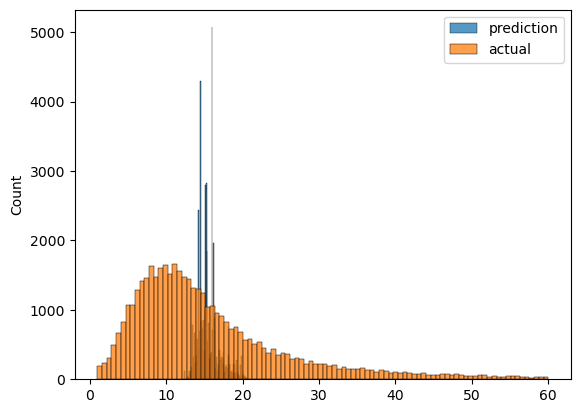

In [32]:
sns.histplot(Y_pred, label = 'prediction')
sns.histplot(Y_train, label = 'actual')

plt.legend()

In [57]:
len(df_val)

44289

In [ ]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_train)